In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('CellobioseTable.xlsx')
df

,Index,collectionPid,ROW_UID,collectionId,nmrResiduePid,peakPid,nmrChainName,nmrResidueCode,nmrResidueType,nmrAtomNames,...,modelName,UncertaintiesMethod,nmrResidueCode-nmrResidueType,0.0,4.6,21.5,99.5,461.3,2137.7,9907.0
0,89,"CO:B.5.THR.N,H_1",NaN,223,NR:B.5.THR,PK:29-1.1.154,B,5,THR,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,5-THR,0,0.001793,0.002473,0.005336,NaN,NaN,0.000688
1,96,"CO:B.6.GLY.N,H_1",NaN,230,NR:B.6.GLY,PK:29-1.1.203,B,6,GLY,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,6-GLY,0,0.002147,0.003082,0.004283,NaN,NaN,0.000862
2,115,"CO:B.7.GLY.N,H_1",NaN,249,NR:B.7.GLY,PK:29-1.1.260,B,7,GLY,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,7-GLY,0,NaN,0.012335,0.004342,0.016117,NaN,0.001999
3,58,"CO:B.8.GLN.N,H_1",NaN,192,NR:B.8.GLN,PK:29-1.1.107,B,8,GLN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,8-GLN,0,0.002261,0.001071,0.002403,NaN,NaN,0.002412
4,119,"CO:B.9.GLN.N,H_1",NaN,253,NR:B.9.GLN,PK:29-1.1.264,B,9,GLN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,9-GLN,0,0.004545,0.002172,0.000783,0.016112,0.019200,0.006430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,60,"CO:@-.@348..N,H_1",NaN,194,NR:@-.@348.,PK:29-1.1.114,@-,@348,NaN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,@348-,0,0.000759,0.000603,0.001387,0.002931,0.012675,0.022451
117,4,"CO:@-.@350..N,H_1",NaN,138,NR:@-.@350.,PK:29-1.1.10,@-,@350,NaN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,@350-,0,0.006867,0.002319,0.002598,0.015663,0.058334,0.133651
118,18,"CO:@-.@351..N,H",NaN,152,NR:@-.@351.,PK:29-1.1.36,@-,@351,NaN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,@351-,0,0.002091,0.001004,0.001727,0.000777,0.000363,0.008250
119,29,"CO:@-.@352..N,H_1",NaN,163,NR:@-.@352.,PK:29-1.1.55,@-,@352,NaN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,@352-,0,0.002735,0.001665,0.002136,0.010570,0.050790,0.144222


In [4]:
resnum = []
for r in df['nmrResidueCode']:
    if r.startswith('@'):
        resnum.append(int(r[1:]))
    else:
        resnum.append(int(r))

<BarContainer object of 121 artists>

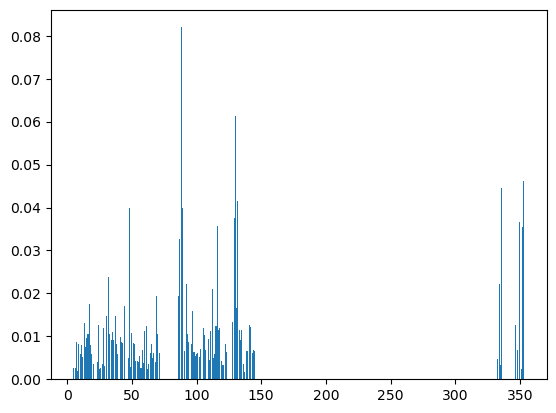

In [5]:
plt.bar(resnum,df['DeltaDelta'])

Text(0.5, 0, 'Side chains')

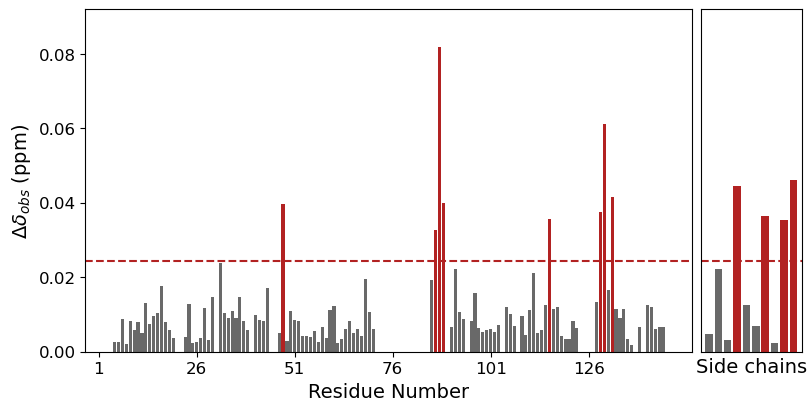

In [6]:
fig, ax = plt.subplot_mosaic(
    [
        ['A', 'A', 'A', 'A', 'A', 'A', 'B'],
    ],
    layout='constrained'
)

fig.set_size_inches(8, 4)
FONT_SIZE=14
TICKS_FONT_SIZE=12
RED_COLOR = 'firebrick'
GREY_COLOR = 'dimgrey'
THRESHOLD = df['DeltaDelta'].mean() + df['DeltaDelta'].std()

# split resnum and df[DeltaDelta] based on the value of  resnum. If it is less than 150, plot in A, otherwise, plot in B
for i, r in enumerate(resnum):
    if r < 150:
        # if dfDeltaDelta is larger than the threshold, color it red, otherwise, color it dimgrey
        if df['DeltaDelta'][i] > THRESHOLD:
            ax['A'].bar(r, df['DeltaDelta'][i], width=0.8, color=RED_COLOR)
        else:
            ax['A'].bar(r, df['DeltaDelta'][i], width=0.8, color=GREY_COLOR)
    else:
        if df['DeltaDelta'][i] > THRESHOLD:
            # for B, make the x-axis values consecutive integers starting from 1
            ax['B'].bar(i - len([x for x in resnum if x < 150]), df['DeltaDelta'][i], width=0.8, color=RED_COLOR)
        else:
            ax['B'].bar(i - len([x for x in resnum if x < 150]), df['DeltaDelta'][i], width=0.8, color=GREY_COLOR)
# add a horizontal line at the threshold value in A
ax['A'].axhline(y=THRESHOLD, color=RED_COLOR, linestyle='--', label='Threshold')
ax['B'].axhline(y=THRESHOLD, color=RED_COLOR, linestyle='--', label='Threshold')

# make A and B have the same y-axis limits
ax['A'].set_ylim(0, df['DeltaDelta'].max() + 0.01)
ax['B'].set_ylim(0, df['DeltaDelta'].max() + 0.01)
# hide the axis and ticks labels for B
ax['B'].set_xticks([])
ax['B'].set_yticks([])

# set tick labels from 1 in A
# set fontsize for xticks and yticks
ax['A'].tick_params(axis='both', which='major', labelsize=TICKS_FONT_SIZE)
ax['A'].set_xticks(range(1, 151, 25))
ax['A'].set_xlabel('Residue Number', fontsize=FONT_SIZE)
ax['A'].set_ylabel(r'$\Delta\delta_{obs}$ (ppm)', fontsize=FONT_SIZE)
ax['B'].set_xlabel('Side chains', fontsize=FONT_SIZE)

<>:74: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:74: SyntaxWarning: "is not" with a literal. Did you mean "!="?
C:\Users\susanntr\AppData\Local\Temp\ipykernel_16216\2201780754.py:74: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if sugar is not 'Sophorose':


select Glucose, resi 87+88+89+116+129+130+132+336+350+352+353+354
select Cellobiose, resi 32+48+69+86+87+88+89+92+112+116+129+130+132+334+336+350+352+353
select Gentiobiose, resi 87+88+89+116+129+130+131+132+336+350
select Laminaribiose, resi 48+87+88+89+116+129+130+131+132+336+350+352+353
select Sophorose, resi 32+48+87+88+89+92+116+129+130+132+336+350


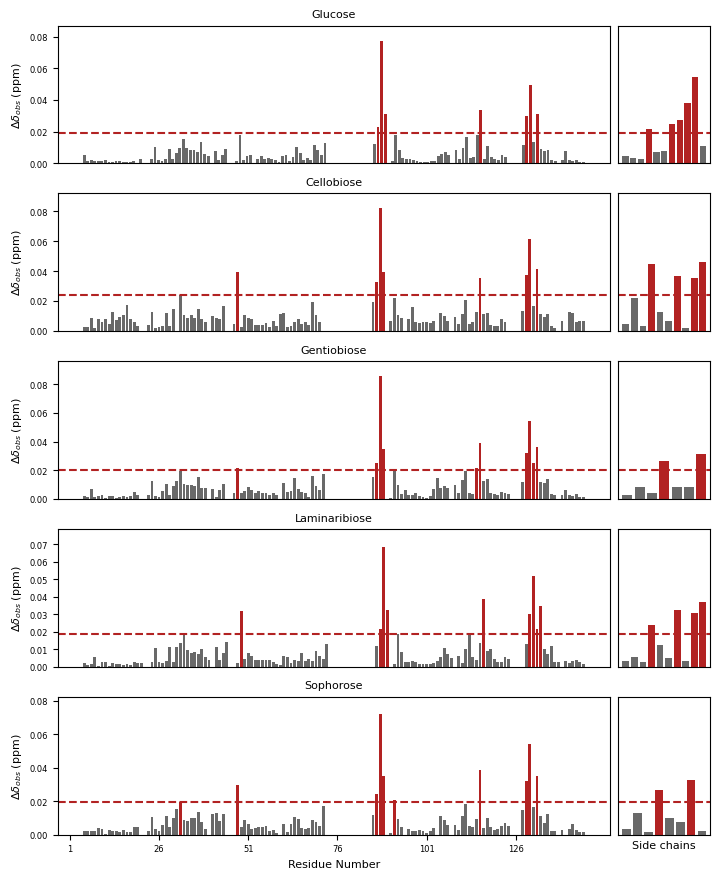

In [16]:
dataset = {
    'Glucose': ['GlucoseTable.xlsx', ['A', 'B']],
    'Cellobiose': ['CellobioseTable.xlsx', ['C', 'D']],
    'Gentiobiose': ['GentiobioseTable.xlsx', ['E', 'F']],
    'Laminaribiose': ['LaminaribioseTable.xlsx', ['G', 'H']],
    'Sophorose': ['SophoroseTable.xlsx', ['I', 'J']],
}

fig, ax = plt.subplot_mosaic(
    [
        ['A', 'A', 'A', 'A', 'A', 'A', 'B'],
        ['C', 'C', 'C', 'C', 'C', 'C', 'D'],
        ['E', 'E', 'E', 'E', 'E', 'E', 'F'],
        ['G', 'G', 'G', 'G', 'G', 'G', 'H'],
        ['I', 'I', 'I', 'I', 'I', 'I', 'J']

    ],
    layout='constrained'
)


width_mm = 180
width_in = width_mm / 25.4  # convert mm → inches
height_in = width_in * 0.35 *3.5 

fig.set_size_inches(width_in, height_in)

for sugar in dataset:


    df = pd.read_excel(dataset[sugar][0])

    resnum = []
    for r in df['nmrResidueCode']:
        if r.startswith('@'):
            resnum.append(int(r[1:]))
        else:
            resnum.append(int(r))

    pymol_selection_string = f'select {sugar}, resi ' + '+'.join([str(x) for x in resnum if df['DeltaDelta'][resnum.index(x)] > THRESHOLD])
    print(pymol_selection_string)
    FONT_SIZE=8
    TICKS_FONT_SIZE=6
    TITLE_FONT_SIZE=8
    RED_COLOR = 'firebrick'
    GREY_COLOR = 'dimgrey'
    THRESHOLD = df['DeltaDelta'].mean() + df['DeltaDelta'].std()

    # split resnum and df[DeltaDelta] based on the value of  resnum. If it is less than 150, plot in A, otherwise, plot in B
    for i, r in enumerate(resnum):
        if r < 150:
            # if dfDeltaDelta is larger than the threshold, color it red, otherwise, color it dimgrey
            if df['DeltaDelta'][i] > THRESHOLD:
                ax[dataset[sugar][1][0]].bar(r, df['DeltaDelta'][i], width=0.8, color=RED_COLOR)
            else:
                ax[dataset[sugar][1][0]].bar(r, df['DeltaDelta'][i], width=0.8, color=GREY_COLOR)
        else:
            if df['DeltaDelta'][i] > THRESHOLD:
                # for B, make the x-axis values consecutive integers starting from 1
                ax[dataset[sugar][1][1]].bar(i - len([x for x in resnum if x < 150]), df['DeltaDelta'][i], width=0.8, color=RED_COLOR)
            else:
                ax[dataset[sugar][1][1]].bar(i - len([x for x in resnum if x < 150]), df['DeltaDelta'][i], width=0.8, color=GREY_COLOR)
    # add a horizontal line at the threshold value in A
    ax[dataset[sugar][1][0]].axhline(y=THRESHOLD, color=RED_COLOR, linestyle='--', label='Threshold')
    ax[dataset[sugar][1][1]].axhline(y=THRESHOLD, color=RED_COLOR, linestyle='--', label='Threshold')

    # make A and B have the same y-axis limits
    ax[dataset[sugar][1][0]].set_ylim(0, df['DeltaDelta'].max() + 0.01)
    ax[dataset[sugar][1][1]].set_ylim(0, df['DeltaDelta'].max() + 0.01)
    # hide the axis and ticks labels for B
    ax[dataset[sugar][1][1]].set_xticks([])
    ax[dataset[sugar][1][1]].set_yticks([])

    if sugar is not 'Sophorose':
        ax[dataset[sugar][1][0]].set_xticks([])
        #ax[dataset[sugar][1][0]].set_yticks([])
    else:
        ax[dataset[sugar][1][0]].set_xlabel('Residue Number', fontsize=FONT_SIZE)
        ax[dataset[sugar][1][1]].set_xlabel('Side chains', fontsize=FONT_SIZE)
        ax[dataset[sugar][1][0]].set_xticks(range(1, 151, 25))


    # set tick labels from 1 in A
    # set fontsize for xticks and yticks
    ax[dataset[sugar][1][0]].tick_params(axis='both', which='major', labelsize=TICKS_FONT_SIZE)

    ax[dataset[sugar][1][0]].set_ylabel(r'$\Delta\delta_{obs}$ (ppm)', fontsize=FONT_SIZE)

    ax[dataset[sugar][1][0]].set_title(sugar, fontsize=TITLE_FONT_SIZE)

plt.savefig('csp_plots.png', dpi=300, bbox_inches='tight')
plt.savefig('csp_plots.svg', bbox_inches='tight')
plt.show()

In [16]:
# compare a range from 1 to 143, if the number is not in resnum, then make a selection in pymol called missing. This is a different selection string than the one above
pymol_selection_string_missing = 'select missing, resi ' + '+'.join([str(x) for x in range(1, 144) if x not in resnum]) 
print(f'Pymol selection string for missing residues: {pymol_selection_string_missing}')

Pymol selection string for missing residues: select missing, resi 1+2+3+4+21+22+40+45+46+47+60+73+74+75+76+77+78+79+80+81+82+83+84+85+95+104+108+125+126+127+138+140


In [17]:
df = pd.read_excel('../GentiobioseTable.xlsx')
df

,Index,collectionPid,ROW_UID,collectionId,nmrResiduePid,peakPid,nmrChainName,nmrResidueCode,nmrResidueType,nmrAtomNames,...,modelName,UncertaintiesMethod,nmrResidueCode-nmrResidueType,0.0,4.0,16.1,64.8,260.4,1046.1,4202.0
0,94,"CO:B.5.THR.H,N",NaN,94,NR:B.5.THR,PK:2-1.1.106,B,5,THR,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,5-THR,0.0,0.001238,0.001358,0.002809,0.002201,0.001677,0.002391
1,101,"CO:B.6.GLY.H,N",NaN,101,NR:B.6.GLY,PK:2-1.1.139,B,6,GLY,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,6-GLY,0.0,0.001519,0.001587,0.001112,0.001162,0.001101,0.002368
2,109,"CO:B.7.GLY.H,N",NaN,109,NR:B.7.GLY,PK:2-1.1.151,B,7,GLY,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,7-GLY,0.0,0.007852,0.003736,0.009078,0.009200,0.006903,0.006098
3,61,"CO:B.8.GLN.H,N",NaN,61,NR:B.8.GLN,PK:2-1.1.67,B,8,GLN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,8-GLN,0.0,0.001663,0.001263,0.001362,0.001710,0.001194,0.000664
4,40,"CO:B.9.GLN.H,N",NaN,40,NR:B.9.GLN,PK:2-1.1.44,B,9,GLN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,9-GLN,0.0,0.002107,0.000783,0.002033,0.003394,0.001433,0.002375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,3,"CO:@-.@335..H,N",NaN,3,NR:@-.@335.,PK:2-1.1.3,@-,@335,NaN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,@335-,0.0,0.002095,0.002523,0.003003,0.003775,0.006359,0.008027
119,8,"CO:@-.@336..H,N",NaN,8,NR:@-.@336.,PK:2-1.1.9,@-,@336,NaN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,@336-,0.0,0.001976,0.002534,0.004540,0.012451,0.039933,0.096525
120,44,"CO:@-.@347..H,N",NaN,44,NR:@-.@347.,PK:2-1.1.48,@-,@347,NaN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,@347-,0.0,0.003119,0.002440,0.000930,0.002553,0.010865,0.030235
121,64,"CO:@-.@348..H,N",NaN,64,NR:@-.@348.,PK:2-1.1.70,@-,@348,NaN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,@348-,0.0,0.001966,0.000902,0.001411,0.003210,0.012167,0.032455


In [21]:
# select rows Q88 and W132 from df and print the new df
new_df = df[(df['nmrResidueCode-nmrResidueType'] == '88-GLN') | (df['nmrResidueCode-nmrResidueType'] == '132-TRP')]
new_df

,Index,collectionPid,ROW_UID,collectionId,nmrResiduePid,peakPid,nmrChainName,nmrResidueCode,nmrResidueType,nmrAtomNames,...,modelName,UncertaintiesMethod,nmrResidueCode-nmrResidueType,0.0,4.0,16.1,64.8,260.4,1046.1,4202.0
64,115,"CO:B.88.GLN.H,N",NaN,115,NR:B.88.GLN,PK:2-1.1.159,B,88,GLN,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,88-GLN,0.0,0.001316,0.005914,0.024150,0.07410,0.174652,0.236219
103,82,"CO:B.132.TRP.H,N",NaN,82,NR:B.132.TRP,PK:2-1.1.92,B,132,TRP,"H,N",...,Fraction Binding with Fixed Target Concentration,Covariance,132-TRP,0.0,0.000734,0.000979,0.003163,0.01497,0.055034,0.140822


[5.75418631e+02 2.70952265e-01]


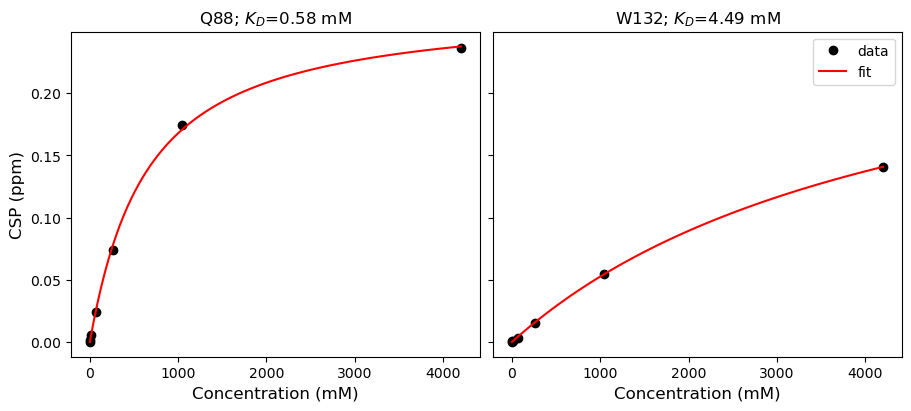

In [52]:
from scipy.optimize import curve_fit

def two_state_model(x, Kd, deltamax):
    # write this equation as a function \Delta \delta_{\text{obs}} = \Delta \delta_{\text{max}} \cdot \frac{\left([P] + [L] + K_D\right) - \sqrt{\left([P] + [L] + K_D\right)^2 - 4[P][L]}}{2[P]}
    P = 100  # assuming [P] = 1 for simplicity
    L = x  # [L] is the concentration
    return deltamax * (P + L + Kd - np.sqrt((P + L + Kd)**2 - 4 * P * L)) / (2 * P)

fig, ax =plt.subplot_mosaic(
    [
        ['A', 'B'],
    ],
    layout='constrained',
    sharey=True
)
# make the figure wide
fig.set_size_inches(9, 4)
#plot the following; x values will be 0.0	4.0	16.1	64.8	260.4	1046.1	4202.0, the y values will be the values of the cells from the columns with these names
x_values = [0.0, 4.0, 16.1, 64.8, 260.4, 1046.1, 4202.0]
x_model = np.linspace(0, 4202, 100)
y_Q88 = new_df[['0.0', '4.0', '16.1', '64.8', '260.4', '1046.1', '4202.0']].values.flatten()[:len(x_values)]
y_W132 = new_df[['0.0', '4.0', '16.1', '64.8', '260.4', '1046.1', '4202.0']].values.flatten()[len(x_values):]

popt, pcov = curve_fit(two_state_model, x_values, y_Q88)
ax['A'].plot(x_values, y_Q88, 'ko', label='data')
ax['A'].plot(x_model, two_state_model(np.array(x_model), *popt), 'r-', label='fit')
ax['A'].set_xlabel('Concentration (mM)', fontsize=FONT_SIZE)
ax['A'].set_ylabel('CSP (ppm)', fontsize=FONT_SIZE)
ax['A'].set_title(f'Q88; $K_D$={popt[0]/1000:.2f} mM', fontsize=FONT_SIZE)
print(popt)
# share y axis with A
popt, pcov = curve_fit(two_state_model, x_values, y_W132)
ax['B'].plot(x_values, y_W132, 'ko', label='data')
ax['B'].plot(x_model, two_state_model(np.array(x_model), *popt), 'r-', label='fit')
ax['B'].set_xlabel('Concentration (mM)', fontsize=FONT_SIZE)
ax['B'].set_title(f'W132; $K_D$={popt[0]/1000:.2f} mM', fontsize=FONT_SIZE)
ax['B'].legend()
plt.savefig('csp_fit.png', dpi=300, bbox_inches='tight')
plt.show()


In [23]:
y_values

array([0.        , 0.0013155 , 0.0059141 , 0.02414971, 0.07409952,
       0.17465195, 0.23621902, 0.        , 0.0007337 , 0.00097907,
       0.00316285, 0.01496992, 0.05503442, 0.14082151])